# 03 — XGBoost Model + Ensemble

Train XGBoost on tabular features, then combine with LSTM predictions via weighted ensemble.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Data

In [2]:
import yfinance as yf
from src.data_loader import clean_data, split_data, scale_data, build_sequences
from src.features import build_features, get_feature_columns

TICKER  = 'AAPL'
START   = '2018-01-01'
END     = '2024-01-01'
SEQ_LEN = 60

df_raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
df_raw.columns = df_raw.columns.get_level_values(0)
df_raw = df_raw[['Open','High','Low','Close','Volume']]

df        = build_features(clean_data(df_raw))
feat_cols = get_feature_columns(df)

train_df, val_df, test_df = split_data(df)
scaled = scale_data(train_df, val_df, test_df,
                    feature_cols=feat_cols, target_col='Close')

print(f'Features: {len(feat_cols)}')

[*********************100%***********************]  1 of 1 completed


[features] Dropped 50 NaN rows after feature engineering.
[features] Final shape: (1459, 33)  |  Columns: 33
[data_loader] Split → train: 1021 | val: 219 | test: 219
[data_loader] Scalers saved → data/processed
Features: 32


## 2. Prepare Tabular Arrays for XGBoost

In [3]:
from src.xgboost_model import prepare_tabular

X_tr_xgb,  y_tr_xgb  = prepare_tabular(scaled['train'], feat_cols, target_col='Close')
X_val_xgb, y_val_xgb = prepare_tabular(scaled['val'],   feat_cols, target_col='Close')
X_te_xgb,  y_te_xgb  = prepare_tabular(scaled['test'],  feat_cols, target_col='Close')

print(f'Train: {X_tr_xgb.shape}  Val: {X_val_xgb.shape}  Test: {X_te_xgb.shape}')

Train: (1021, 32)  Val: (219, 32)  Test: (219, 32)


## 3. Train XGBoost

In [4]:
from src.xgboost_model import build_xgboost, train_xgboost

xgb_model = build_xgboost(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=30,
)

xgb_model = train_xgboost(
    xgb_model,
    X_tr_xgb, y_tr_xgb,
    X_val_xgb, y_val_xgb,
)

[xgboost] Training on 1021 samples | Validating on 219 samples | Features: 32
[0]	validation_0-rmse:0.28509	validation_1-rmse:0.39189
[50]	validation_0-rmse:0.02487	validation_1-rmse:0.03310
[100]	validation_0-rmse:0.00444	validation_1-rmse:0.00703
[150]	validation_0-rmse:0.00281	validation_1-rmse:0.00556
[200]	validation_0-rmse:0.00251	validation_1-rmse:0.00535
[250]	validation_0-rmse:0.00239	validation_1-rmse:0.00527
[300]	validation_0-rmse:0.00233	validation_1-rmse:0.00524
[350]	validation_0-rmse:0.00231	validation_1-rmse:0.00521
[400]	validation_0-rmse:0.00229	validation_1-rmse:0.00521
[450]	validation_0-rmse:0.00229	validation_1-rmse:0.00520
[499]	validation_0-rmse:0.00228	validation_1-rmse:0.00520
[xgboost] Best iteration: 485  |  Val RMSE: 0.005201


## 4. XGBoost Evaluation

In [5]:
from src.xgboost_model import evaluate_xgboost, plot_feature_importance

xgb_result = evaluate_xgboost(
    xgb_model, X_te_xgb, y_te_xgb,
    target_scaler=scaled['target_scaler'],
    save_dir='../results',
)

print('\nXGBoost Test Metrics:')
for k, v in xgb_result['metrics'].items():
    print(f'  {k:<25}: {v:.4f}')


── XGBoost Metrics ─────────────────────
  MAE                      : 6.2862
  RMSE                     : 9.5249
  MAPE                     : 3.3655
  Directional_Accuracy     : 75.2294

[xgboost] Prediction plot saved → ../results\plots\xgboost_predictions.png

XGBoost Test Metrics:
  MAE                      : 6.2862
  RMSE                     : 9.5249
  MAPE                     : 3.3655
  Directional_Accuracy     : 75.2294


[xgboost] Feature importance plot saved → ../results/plots\xgboost_feature_importance.png


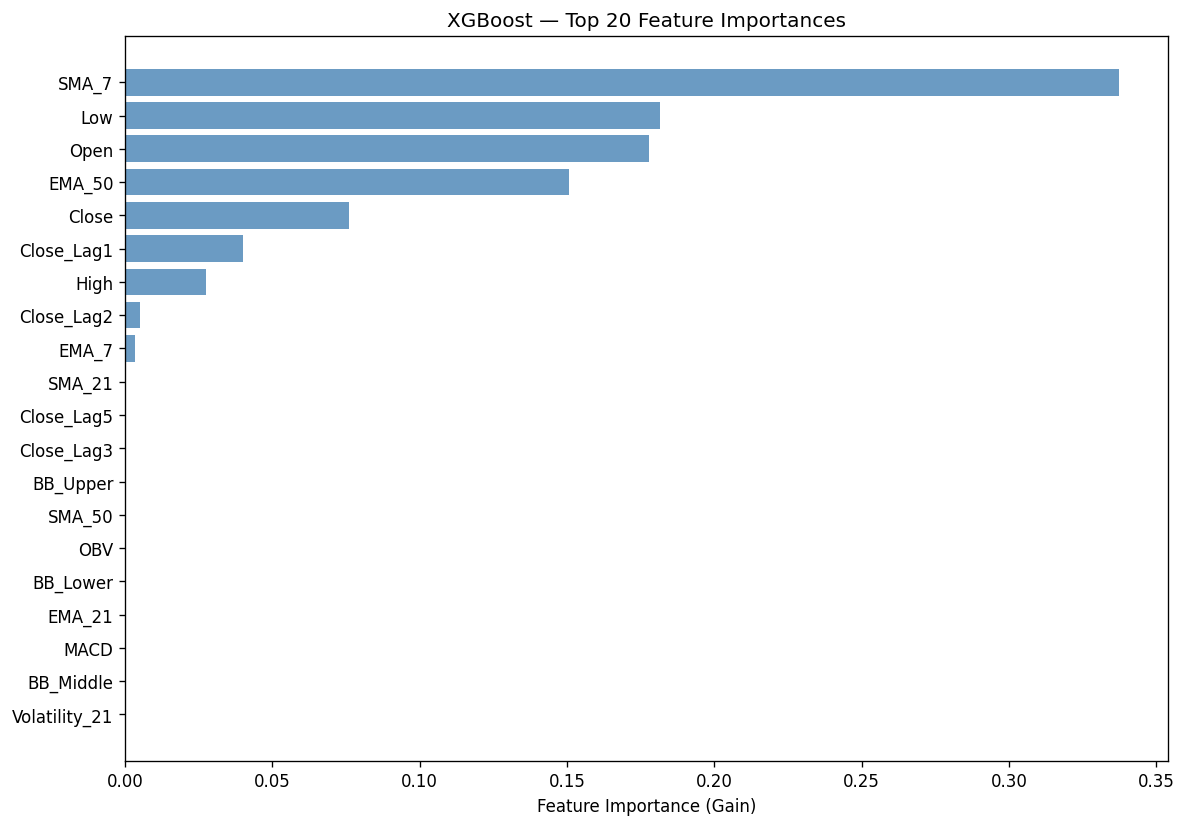

In [6]:
# Feature importance
plot_feature_importance(xgb_model, feat_cols, top_n=20, save_dir='../results/plots')

# Show inline
importance = xgb_model.feature_importances_
pairs = sorted(zip(feat_cols, importance), key=lambda x: x[1], reverse=True)[:20]
names, scores = zip(*pairs)

plt.figure(figsize=(10, 7))
plt.barh(range(len(names)), scores[::-1], color='steelblue', alpha=0.8)
plt.yticks(range(len(names)), names[::-1])
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost — Top 20 Feature Importances')
plt.tight_layout(); plt.show()

## 5. Load LSTM Predictions

> Run notebook 02 first to generate the LSTM results and saved model.

In [7]:
from src.lstm_model import load_lstm
from src.data_loader import build_sequences

lstm_model = load_lstm('../results/lstm_final.keras')

X_test, y_test = build_sequences(scaled['test'], feat_cols, seq_len=SEQ_LEN)

y_pred_lstm_scaled = lstm_model.predict(X_test).flatten()
target_scaler      = scaled['target_scaler']

y_pred_lstm = target_scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()
y_true      = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Align lengths (XGBoost test set may be longer — trim to LSTM length)
min_len      = min(len(y_true), len(xgb_result['y_pred']))
y_true       = y_true[:min_len]
y_pred_lstm  = y_pred_lstm[:min_len]
y_pred_xgb   = xgb_result['y_pred'][:min_len]

print(f'Aligned test set length: {min_len}')

[lstm] Model loaded ← ../results/lstm_final.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step
Aligned test set length: 159


## 6. Ensemble — Find Optimal Weights

In [8]:
from src.ensemble import find_optimal_weights, weighted_ensemble

# Use first half of test set as pseudo-validation for weight search
mid = min_len // 2
best_w = find_optimal_weights(
    y_true[:mid], y_pred_lstm[:mid], y_pred_xgb[:mid], metric='rmse'
)

# Apply to full test set
y_pred_ens = weighted_ensemble(y_pred_lstm, y_pred_xgb, lstm_weight=best_w)
print(f'Ensemble predictions generated with LSTM weight = {best_w}')

[ensemble] Optimal LSTM weight: 1.0  |  Best val RMSE: 9.984978
[ensemble] Weighted average  →  LSTM: 1.00 | XGB: 0.00
Ensemble predictions generated with LSTM weight = 1.0


## 7. Final Comparison

In [9]:
from src.evaluate import compute_all_metrics, metrics_table, plot_dashboard, save_metrics_csv

results = [
    compute_all_metrics(y_true, y_pred_lstm, 'LSTM'),
    compute_all_metrics(y_true, y_pred_xgb,  'XGBoost'),
    compute_all_metrics(y_true, y_pred_ens,  'Ensemble'),
]

table = metrics_table(results)
save_metrics_csv(table, save_dir='../results')
table


╔══════════════════════════════════════════════════╗
║           Final Model Comparison Table           ║
╠══════════════════════════════════════════════════╣
              MAE     RMSE  MAPE (%)      R²  Directional_Acc (%)
Model                                                            
LSTM       8.8144  10.3880    4.7535 -0.6394                47.47
XGBoost   14.9059  18.1963    8.1080 -4.0303                50.63
Ensemble   8.8144  10.3880    4.7535 -0.6394                47.47
╚══════════════════════════════════════════════════╝

[evaluate] Metrics saved → ../results\metrics.csv


,MAE,RMSE,MAPE (%),R²,Directional_Acc (%)
Model,,,,,
LSTM,8.8144,10.3880,4.7535,-0.6394,47.47
XGBoost,14.9059,18.1963,8.1080,-4.0303,50.63
Ensemble,8.8144,10.3880,4.7535,-0.6394,47.47


## 8. Dashboard Plot

In [10]:
plot_dashboard(y_true, y_pred_lstm, y_pred_xgb, y_pred_ens,
               ticker=TICKER, save_dir='../results/plots')

[evaluate] Dashboard saved → ../results/plots\AAPL_dashboard.png


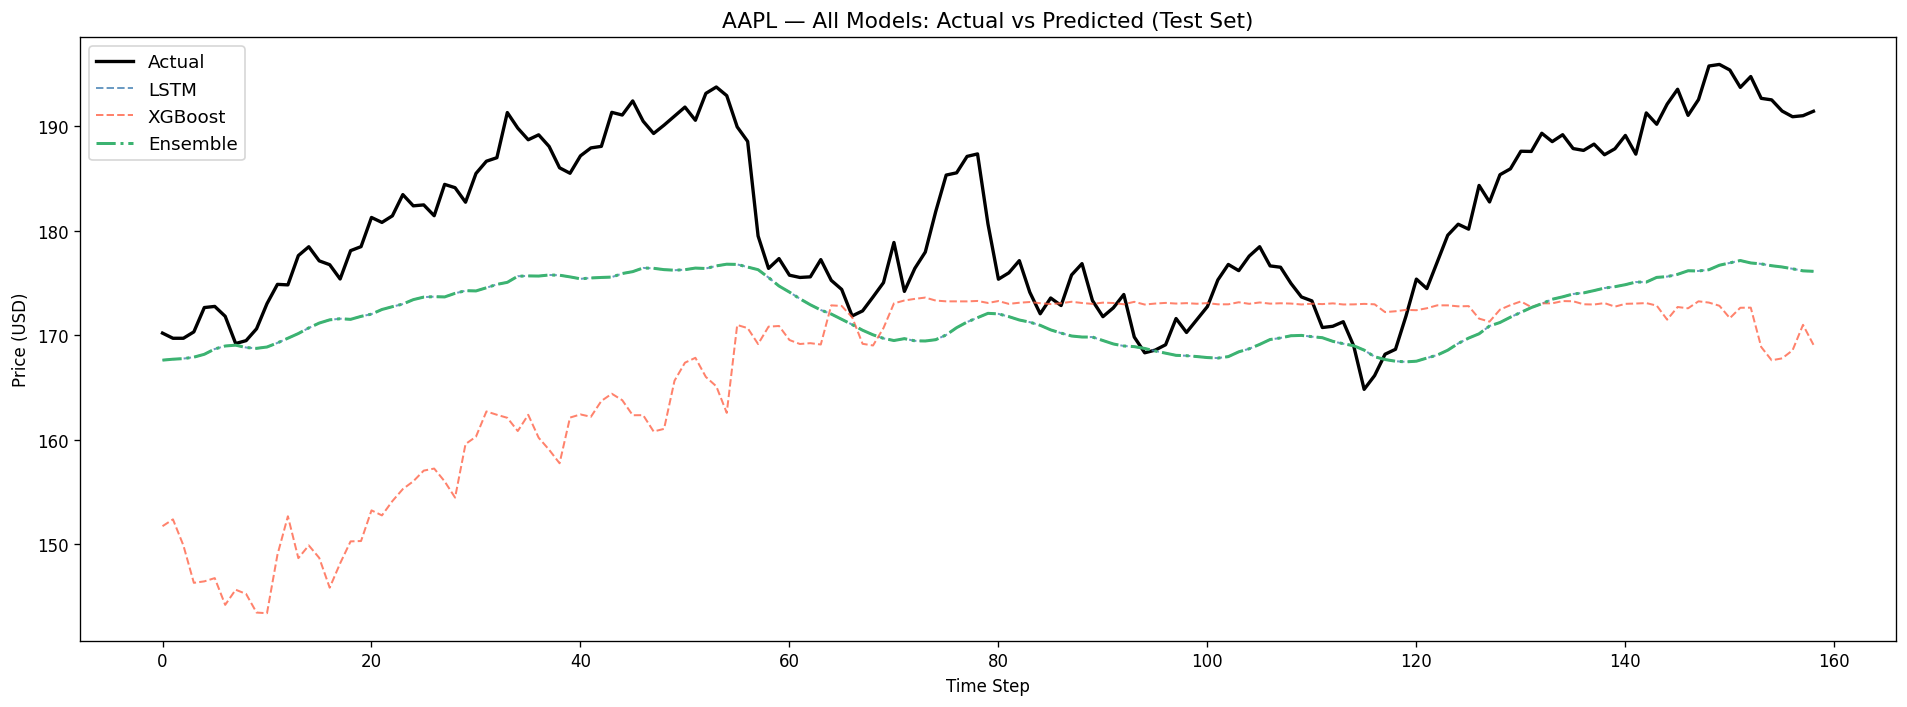

In [11]:
# Inline comparison plot
plt.figure(figsize=(16, 6))
plt.plot(y_true,      label='Actual',    color='black',           linewidth=2.0)
plt.plot(y_pred_lstm, label='LSTM',      color='steelblue',       linewidth=1.2, linestyle='--', alpha=0.8)
plt.plot(y_pred_xgb,  label='XGBoost',  color='tomato',          linewidth=1.2, linestyle='--', alpha=0.8)
plt.plot(y_pred_ens,  label='Ensemble', color='mediumseagreen',  linewidth=1.8, linestyle='-.')
plt.title(f'{TICKER} — All Models: Actual vs Predicted (Test Set)', fontsize=13)
plt.xlabel('Time Step'); plt.ylabel('Price (USD)')
plt.legend(fontsize=11); plt.tight_layout(); plt.show()

## 9. Save XGBoost Model

In [12]:
from src.xgboost_model import save_xgboost
save_xgboost(xgb_model, path='../results/xgboost_final.pkl')
print('\nAll done! ✓')
print('Results saved to: results/')

[xgboost] Model saved → ../results/xgboost_final.pkl

All done! ✓
Results saved to: results/
